In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from river import drift

from sklearn.metrics import log_loss, roc_auc_score, accuracy_score

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

DATA_PATH = Path("click_prediction.csv")
MODEL_A_PATH = Path("add_model_A.json")
MODEL_B_PATH = Path("add_model_B.json")

In [14]:
TARGET_COL = "clickedonadd"

FEATURE_COLS = [
    "id", "year", "dayofyear", "timeofday",
    "devicetype", "location", "age", "browser", "OS", "adstylecategory",
    "partofaddevaluationfocusgroup", "providedfeedbackaboutadd",
    "visitedgood0", "visitedgood1", "visitedgood2", "visitedgood3", "visitedgood4",
    "visitedgood5", "visitedgood6", "visitedgood7", "visitedgood8", "visitedgood9",
    "purchasedgood0", "purchasedgood1", "purchasedgood2", "purchasedgood3", "purchasedgood4",
    "purchasedgood5", "purchasedgood6", "purchasedgood7", "purchasedgood8", "purchasedgood9",
]

In [15]:
COLUMN_RENAME_MAP = {
    "day_of_year": "dayofyear",
    "time_of_day": "timeofday",
    "device_type": "devicetype",
    "ad_style_category": "adstylecategory",
    "part_of_add_evaluation_focus_group": "partofaddevaluationfocusgroup",
    "provided_feedback_about_add": "providedfeedbackaboutadd",
    "clicked_on_add": "clickedonadd",
}

# visited_good_0 -> visitedgood0, ..., visited_good_9 -> visitedgood9
for i in range(10):
    COLUMN_RENAME_MAP[f"visited_good_{i}"] = f"visitedgood{i}"
    COLUMN_RENAME_MAP[f"purchased_good_{i}"] = f"purchasedgood{i}"

In [16]:
def read_click_data(path: Path) -> pd.DataFrame:
    for sep in [",", ";", "\t", "|"]:
        try:
            df_try = pd.read_csv(path, sep=sep)
            if len(df_try.columns) > 10:
                return df_try
        except Exception:
            pass
    return pd.read_csv(path)

def ensure_expected_columns(df: pd.DataFrame):
    missing = [c for c in (FEATURE_COLS + [TARGET_COL]) if c not in df.columns]
    if missing:
        raise ValueError(
            f"Still missing columns AFTER renaming: {missing}\n"
            f"Available columns (first 80): {list(df.columns)[:80]}"
        )

def load_xgb_json_model(model_path: Path) -> XGBClassifier:
    m = XGBClassifier()
    m.load_model(model_path)
    return m

def contiguous_time_split(df_sorted: pd.DataFrame, train_frac: float, base_frac: float):
    n = len(df_sorted)
    n_train = int(round(train_frac * n))
    n_base = int(round(base_frac * n))
    n_train = max(1, min(n_train, n - 2))
    n_base = max(1, min(n_base, n - n_train - 1))
    train = df_sorted.iloc[:n_train].copy()
    base  = df_sorted.iloc[n_train:n_train + n_base].copy()
    test  = df_sorted.iloc[n_train + n_base:].copy()
    return train, base, test

def rolling_mean(x: np.ndarray, window: int) -> np.ndarray:
    return pd.Series(x).rolling(window=window, min_periods=max(5, window // 10)).mean().to_numpy()

In [17]:
TRAIN_FRAC = 0.50
BASE_FRAC  = 0.20
ROLLING_WINDOW = 300

CUSUM_K_FACTOR = 0.5
CUSUM_H_FACTOR = 15.0
PH_DELTA_FACTOR = 0.01
PH_THRESHOLD_FACTOR = 50.0

In [18]:
df = read_click_data(DATA_PATH)

# 1) Rename your CSV columns to the model-expected names
df = df.rename(columns=COLUMN_RENAME_MAP)

# 2) (Optional) drop extra "raw" columns if present
raw_cols = [c for c in df.columns if c.endswith("_raw") or c.endswith("_ids_raw")]
if raw_cols:
    df = df.drop(columns=raw_cols)

# 3) Now check we have everything we need
ensure_expected_columns(df)

# 4) Keep only the needed columns and make sure they are numeric
df = df[FEATURE_COLS + [TARGET_COL]].copy()
df = df.apply(pd.to_numeric, errors="coerce").dropna(axis=0).reset_index(drop=True)

# 5) Sort by time (past -> future stream)
df = df.sort_values(["year", "dayofyear", "timeofday"], ascending=True).reset_index(drop=True)

train_df, base_df, test_df = contiguous_time_split(df, TRAIN_FRAC, BASE_FRAC)

print("Sizes: train, base, test =", len(train_df), len(base_df), len(test_df))
print("Base click rate:", round(base_df[TARGET_COL].mean(), 4))
print("Test click rate:", round(test_df[TARGET_COL].mean(), 4))

Sizes: train, base, test = 25000 10000 15000
Base click rate: 0.4499
Test click rate: 0.4525


In [20]:
modelA = load_xgb_json_model(MODEL_A_PATH)
modelB = load_xgb_json_model(MODEL_B_PATH)

print("Loaded Model A and Model B.")

Loaded Model A and Model B.


In [21]:
def run_stream_drift(model: XGBClassifier, df_train: pd.DataFrame, df_base: pd.DataFrame, df_test: pd.DataFrame, name: str):
    X_train = df_train[FEATURE_COLS]
    y_train = df_train[TARGET_COL].astype(int).to_numpy()

    X_base = df_base[FEATURE_COLS]
    y_base = df_base[TARGET_COL].astype(int).to_numpy()

    X_test = df_test[FEATURE_COLS]
    y_test = df_test[TARGET_COL].astype(int).to_numpy()

    # Predict probabilities
    p1_train = model.predict_proba(X_train)[:, 1]
    p1_base  = model.predict_proba(X_base)[:, 1]
    p1_test  = model.predict_proba(X_test)[:, 1]

    metrics_train = evaluate_global_metrics(y_train, p1_train)
    metrics_base  = evaluate_global_metrics(y_base, p1_base)
    metrics_test  = evaluate_global_metrics(y_test, p1_test)

    # Baseline signals
    base_ll = np.array([per_sample_logloss(int(yt), float(p)) for yt, p in zip(y_base, p1_base)], dtype=float)
    base_err01 = ((p1_base >= 0.5).astype(int) != y_base).astype(float)

    ll_mu = float(base_ll.mean())
    ll_std = float(base_ll.std() if base_ll.std() > 0 else 1e-6)

    err_mu = float(base_err01.mean())
    err_std = float(base_err01.std() if base_err01.std() > 0 else 1e-6)

    # CUSUM parameters (lecture-style) [file:4]
    cusum_ll = SimpleCUSUM(mu0=ll_mu, k=CUSUM_K_FACTOR * ll_std, threshold=CUSUM_H_FACTOR * ll_std)
    cusum_er = SimpleCUSUM(mu0=err_mu, k=CUSUM_K_FACTOR * err_std, threshold=CUSUM_H_FACTOR * err_std)

    # Page-Hinkley parameters (lecture-style using river) [file:4]
    ph_ll = drift.PageHinkley(min_instances=1000, delta=PH_DELTA_FACTOR * ll_std, threshold=PH_THRESHOLD_FACTOR * ll_std)
    ph_er = drift.PageHinkley(min_instances=1000, delta=PH_DELTA_FACTOR * err_std, threshold=PH_THRESHOLD_FACTOR * err_std)

    # Stream through TEST
    t = np.arange(len(df_test), dtype=int)

    test_ll = np.zeros(len(df_test), dtype=float)
    test_err01 = np.zeros(len(df_test), dtype=float)

    cusum_ll_stats = np.zeros(len(df_test), dtype=float)
    cusum_er_stats = np.zeros(len(df_test), dtype=float)

    cusum_ll_first = None
    cusum_er_first = None
    ph_ll_first = None
    ph_er_first = None

    for i in range(len(df_test)):
        yt = int(y_test[i])
        p1 = float(p1_test[i])

        ll = per_sample_logloss(yt, p1)
        e01 = float(int((p1 >= 0.5)) != yt)

        test_ll[i] = ll
        test_err01[i] = e01

        # CUSUM updates
        cusum_ll_stats[i] = cusum_ll.update(ll)
        cusum_er_stats[i] = cusum_er.update(e01)

        if cusum_ll.drift_detected and cusum_ll_first is None:
            cusum_ll_first = i
        if cusum_er.drift_detected and cusum_er_first is None:
            cusum_er_first = i

        # Page-Hinkley updates
        ph_ll.update(ll)
        ph_er.update(e01)
        if ph_ll.drift_detected and ph_ll_first is None:
            ph_ll_first = i
        if ph_er.drift_detected and ph_er_first is None:
            ph_er_first = i

    return {
        "name": name,
        "metrics_train": metrics_train,
        "metrics_base": metrics_base,
        "metrics_test": metrics_test,
        "t": t,
        "test_ll": test_ll,
        "test_err01": test_err01,
        "p1_test": p1_test,
        "y_test": y_test,
        "cusum_ll_stats": cusum_ll_stats,
        "cusum_er_stats": cusum_er_stats,
        "cusum_ll_first": cusum_ll_first,
        "cusum_er_first": cusum_er_first,
        "ph_ll_first": ph_ll_first,
        "ph_er_first": ph_er_first,
        "cusum_ll_threshold": cusum_ll.threshold,
        "cusum_er_threshold": cusum_er.threshold,
    }

In [22]:
resA = run_stream_drift(modelA, train_df, base_df, test_df, name="Model A")
resB = run_stream_drift(modelB, train_df, base_df, test_df, name="Model B")

for res in [resA, resB]:
    print("\n---", res["name"], "---")
    print("Train:", res["metrics_train"])
    print("Base :", res["metrics_base"])
    print("Test :", res["metrics_test"])
    print("First drift index (logloss): CUSUM =", res["cusum_ll_first"], ", Page-Hinkley =", res["ph_ll_first"])
    print("First drift index (0/1 err): CUSUM =", res["cusum_er_first"], ", Page-Hinkley =", res["ph_er_first"])


--- Model A ---
Train: {'accuracy@0.5': 0.73592, 'roc_auc': 0.7904277582145969, 'logloss': 0.5007454191588356}
Base : {'accuracy@0.5': 0.7326, 'roc_auc': 0.7885036885734248, 'logloss': 0.5016783188314495}
Test : {'accuracy@0.5': 0.7318, 'roc_auc': 0.7901689044585006, 'logloss': 0.5030080978089715}
First drift index (logloss): CUSUM = None , Page-Hinkley = 1975
First drift index (0/1 err): CUSUM = None , Page-Hinkley = 2041

--- Model B ---
Train: {'accuracy@0.5': 0.61972, 'roc_auc': 0.6528134558057401, 'logloss': 0.6403363592369575}
Base : {'accuracy@0.5': 0.608, 'roc_auc': 0.6389823483365933, 'logloss': 0.6478338569194987}
Test : {'accuracy@0.5': 0.6138666666666667, 'roc_auc': 0.6525169850161004, 'logloss': 0.6415101415523765}
First drift index (logloss): CUSUM = 10762 , Page-Hinkley = 2226
First drift index (0/1 err): CUSUM = None , Page-Hinkley = 2212


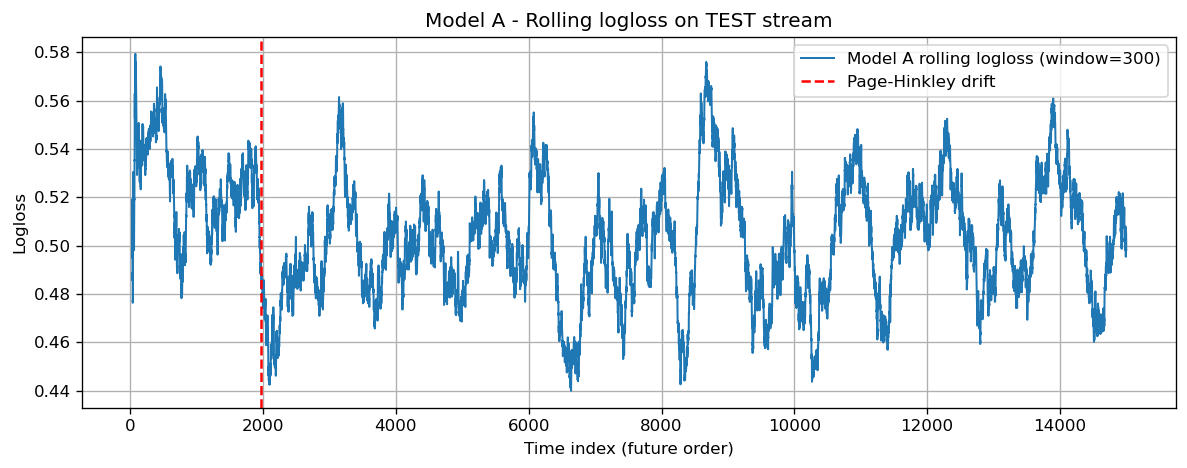

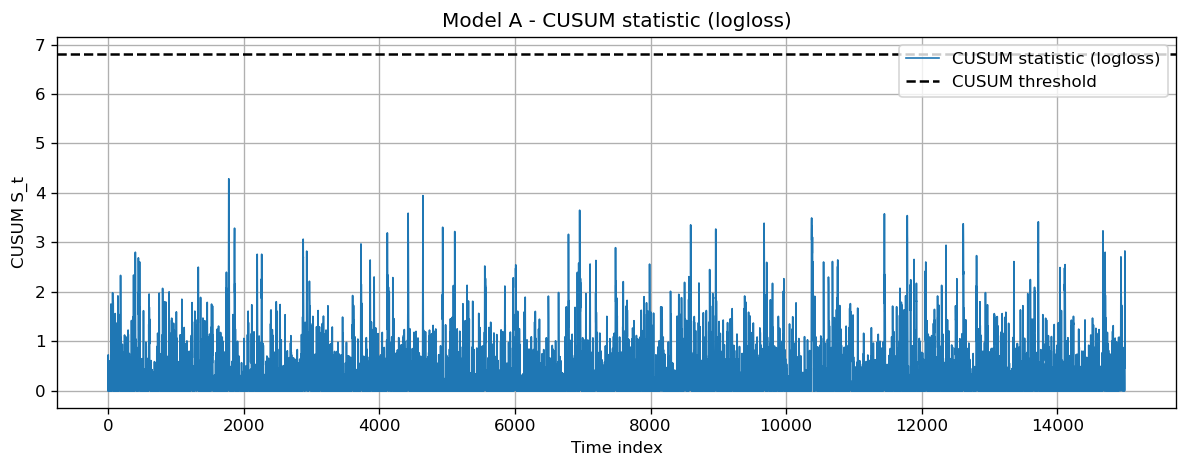

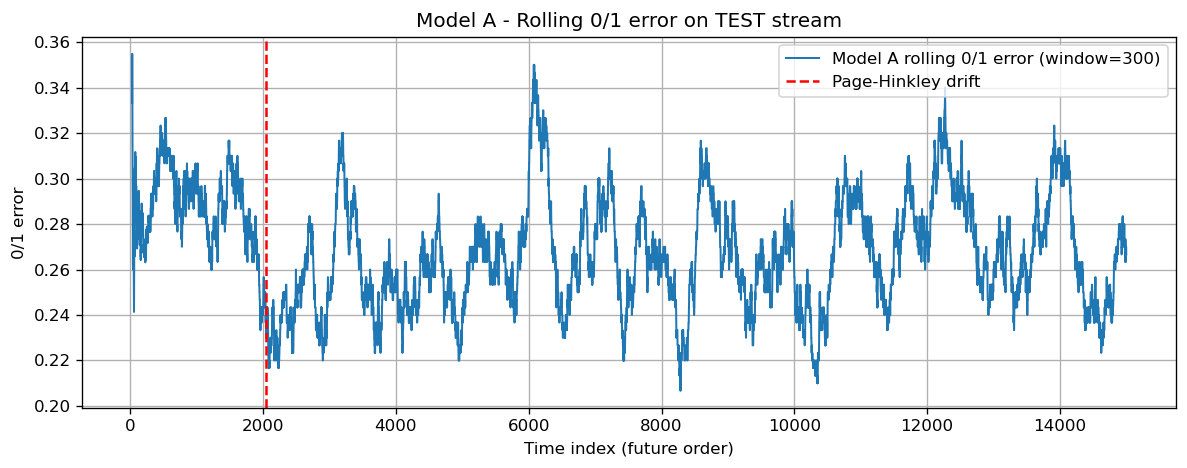

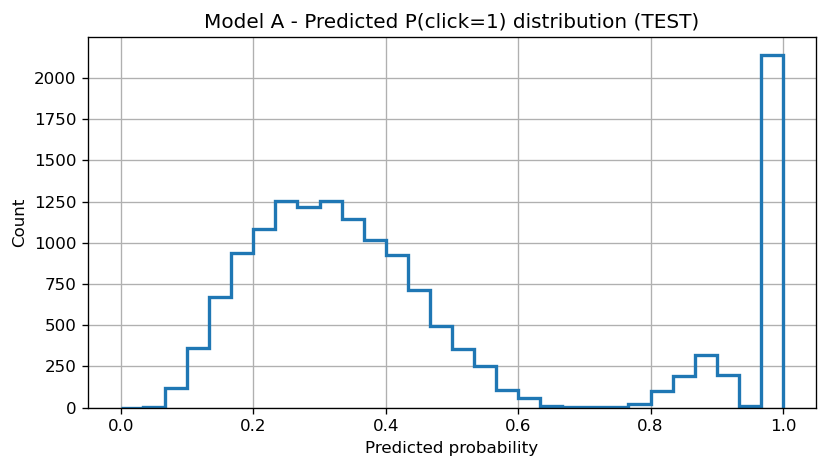

In [23]:
def plot_model(res):
    name = res["name"]
    t = res["t"]

    ll_roll = rolling_mean(res["test_ll"], ROLLING_WINDOW)
    er_roll = rolling_mean(res["test_err01"], ROLLING_WINDOW)

    # 1) Rolling logloss
    plt.figure(figsize=(10, 4))
    plt.plot(t, ll_roll, label=f"{name} rolling logloss (window={ROLLING_WINDOW})", linewidth=1.2)
    if res["cusum_ll_first"] is not None:
        plt.axvline(res["cusum_ll_first"], color="green", linestyle="--", label="CUSUM drift")
    if res["ph_ll_first"] is not None:
        plt.axvline(res["ph_ll_first"], color="red", linestyle="--", label="Page-Hinkley drift")
    plt.title(f"{name} - Rolling logloss on TEST stream")
    plt.xlabel("Time index (future order)")
    plt.ylabel("Logloss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) CUSUM logloss statistic
    plt.figure(figsize=(10, 4))
    plt.plot(t, res["cusum_ll_stats"], label="CUSUM statistic (logloss)", linewidth=1.0)
    plt.axhline(res["cusum_ll_threshold"], color="black", linestyle="--", label="CUSUM threshold")
    if res["cusum_ll_first"] is not None:
        plt.axvline(res["cusum_ll_first"], color="green", linestyle="--", label="CUSUM drift")
    plt.title(f"{name} - CUSUM statistic (logloss)")
    plt.xlabel("Time index")
    plt.ylabel("CUSUM S_t")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Rolling 0/1 error
    plt.figure(figsize=(10, 4))
    plt.plot(t, er_roll, label=f"{name} rolling 0/1 error (window={ROLLING_WINDOW})", linewidth=1.2)
    if res["cusum_er_first"] is not None:
        plt.axvline(res["cusum_er_first"], color="green", linestyle="--", label="CUSUM drift")
    if res["ph_er_first"] is not None:
        plt.axvline(res["ph_er_first"], color="red", linestyle="--", label="Page-Hinkley drift")
    plt.title(f"{name} - Rolling 0/1 error on TEST stream")
    plt.xlabel("Time index (future order)")
    plt.ylabel("0/1 error")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) Probability histogram
    plt.figure(figsize=(7, 4))
    plt.hist(res["p1_test"], bins=30, range=(0, 1), histtype="step", linewidth=2)
    plt.title(f"{name} - Predicted P(click=1) distribution (TEST)")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_model(resA)  # change to resB for model B

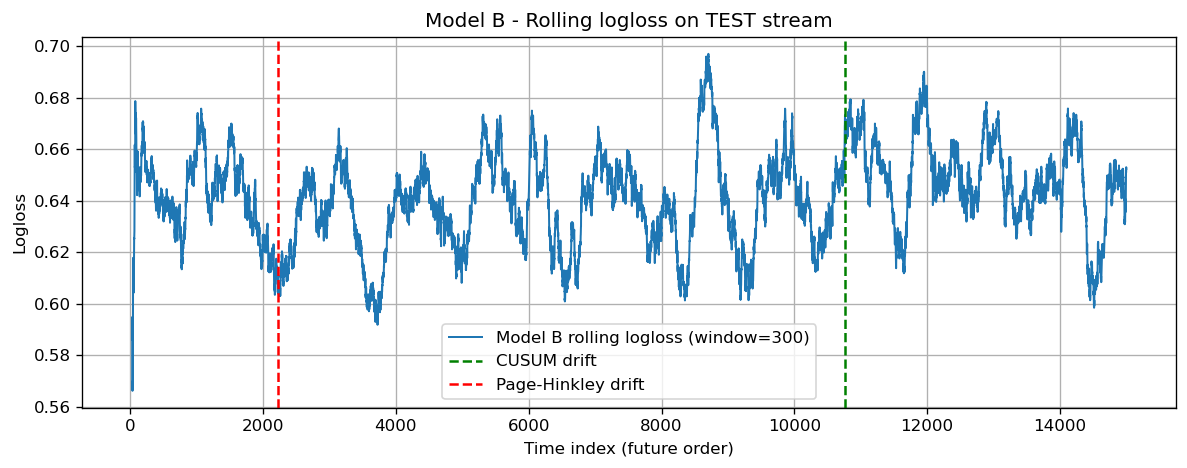

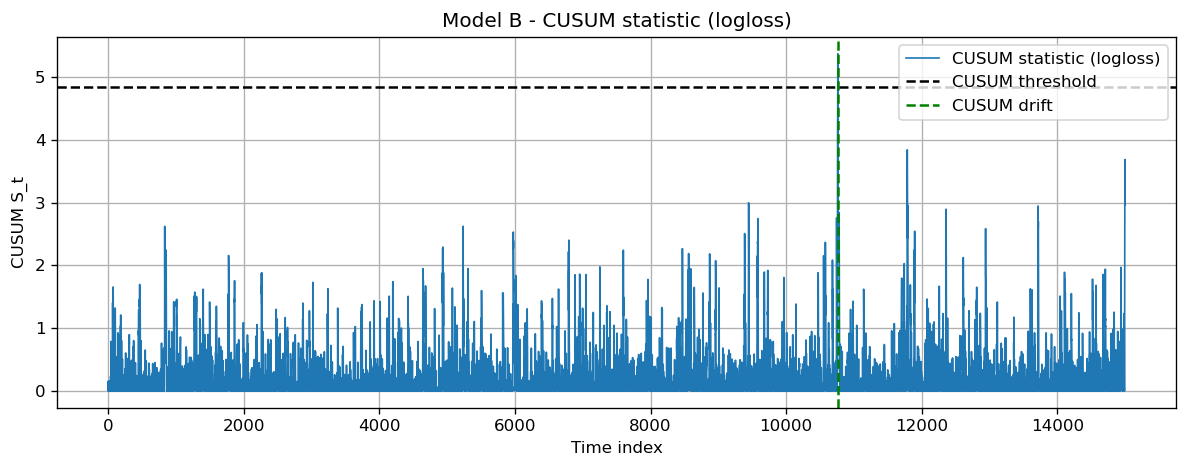

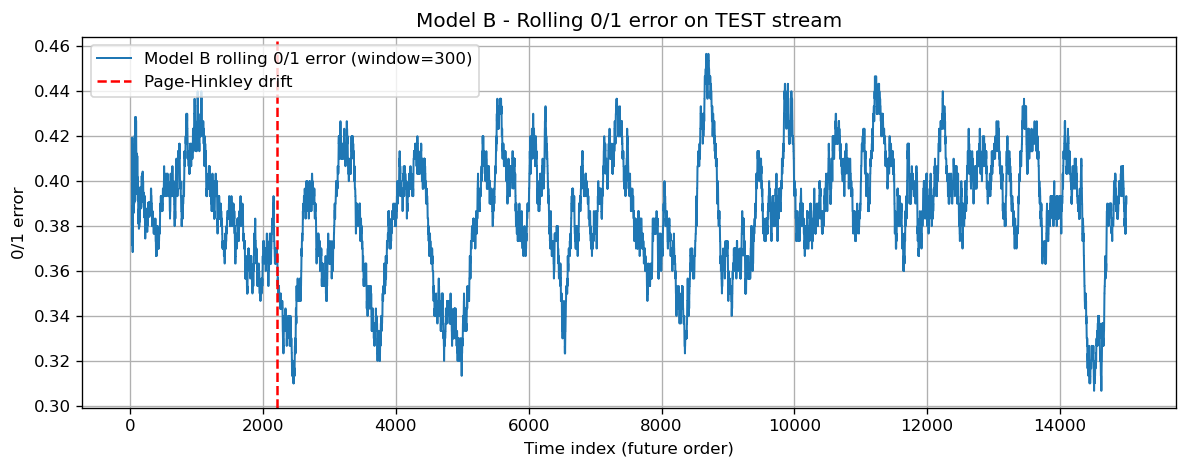

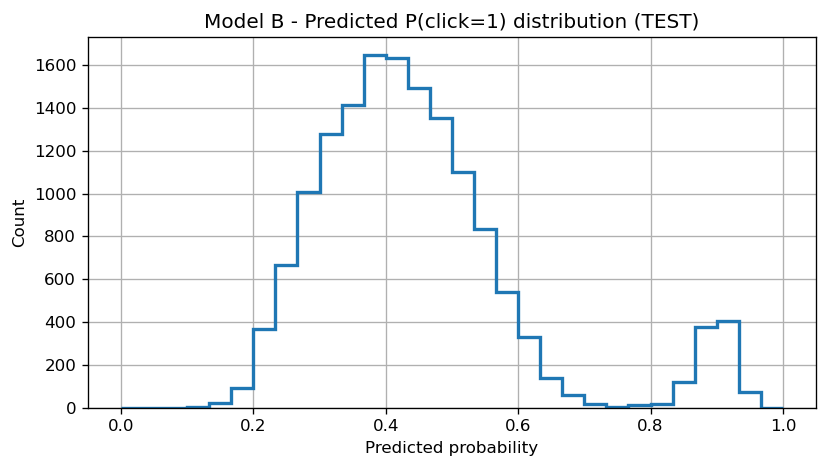

In [26]:
def plot_model(res):
    name = res["name"]
    t = res["t"]

    ll_roll = rolling_mean(res["test_ll"], ROLLING_WINDOW)
    er_roll = rolling_mean(res["test_err01"], ROLLING_WINDOW)

    # 1) Rolling logloss
    plt.figure(figsize=(10, 4))
    plt.plot(t, ll_roll, label=f"{name} rolling logloss (window={ROLLING_WINDOW})", linewidth=1.2)
    if res["cusum_ll_first"] is not None:
        plt.axvline(res["cusum_ll_first"], color="green", linestyle="--", label="CUSUM drift")
    if res["ph_ll_first"] is not None:
        plt.axvline(res["ph_ll_first"], color="red", linestyle="--", label="Page-Hinkley drift")
    plt.title(f"{name} - Rolling logloss on TEST stream")
    plt.xlabel("Time index (future order)")
    plt.ylabel("Logloss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) CUSUM logloss statistic
    plt.figure(figsize=(10, 4))
    plt.plot(t, res["cusum_ll_stats"], label="CUSUM statistic (logloss)", linewidth=1.0)
    plt.axhline(res["cusum_ll_threshold"], color="black", linestyle="--", label="CUSUM threshold")
    if res["cusum_ll_first"] is not None:
        plt.axvline(res["cusum_ll_first"], color="green", linestyle="--", label="CUSUM drift")
    plt.title(f"{name} - CUSUM statistic (logloss)")
    plt.xlabel("Time index")
    plt.ylabel("CUSUM S_t")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Rolling 0/1 error
    plt.figure(figsize=(10, 4))
    plt.plot(t, er_roll, label=f"{name} rolling 0/1 error (window={ROLLING_WINDOW})", linewidth=1.2)
    if res["cusum_er_first"] is not None:
        plt.axvline(res["cusum_er_first"], color="green", linestyle="--", label="CUSUM drift")
    if res["ph_er_first"] is not None:
        plt.axvline(res["ph_er_first"], color="red", linestyle="--", label="Page-Hinkley drift")
    plt.title(f"{name} - Rolling 0/1 error on TEST stream")
    plt.xlabel("Time index (future order)")
    plt.ylabel("0/1 error")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) Probability histogram
    plt.figure(figsize=(7, 4))
    plt.hist(res["p1_test"], bins=30, range=(0, 1), histtype="step", linewidth=2)
    plt.title(f"{name} - Predicted P(click=1) distribution (TEST)")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_model(resB)  # change to resB for model B

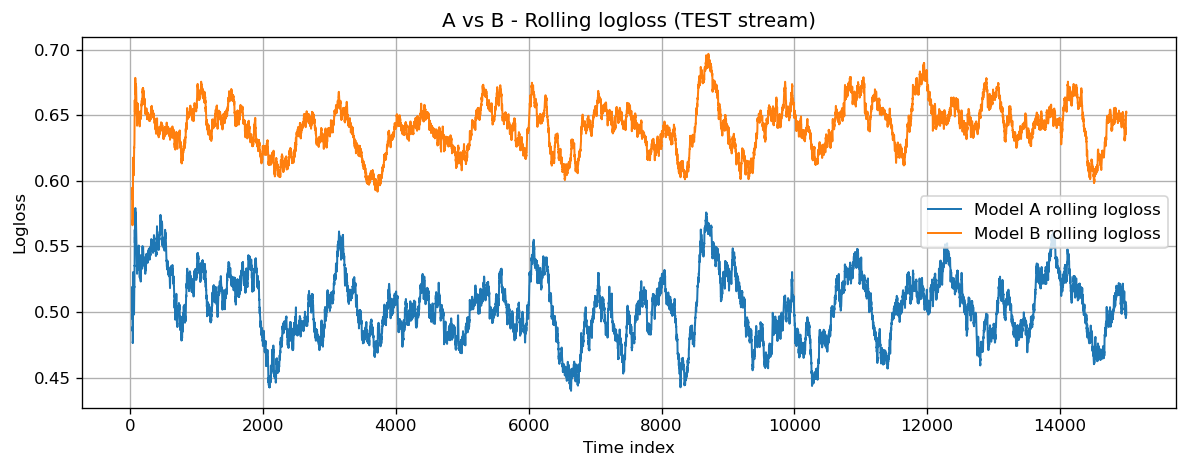

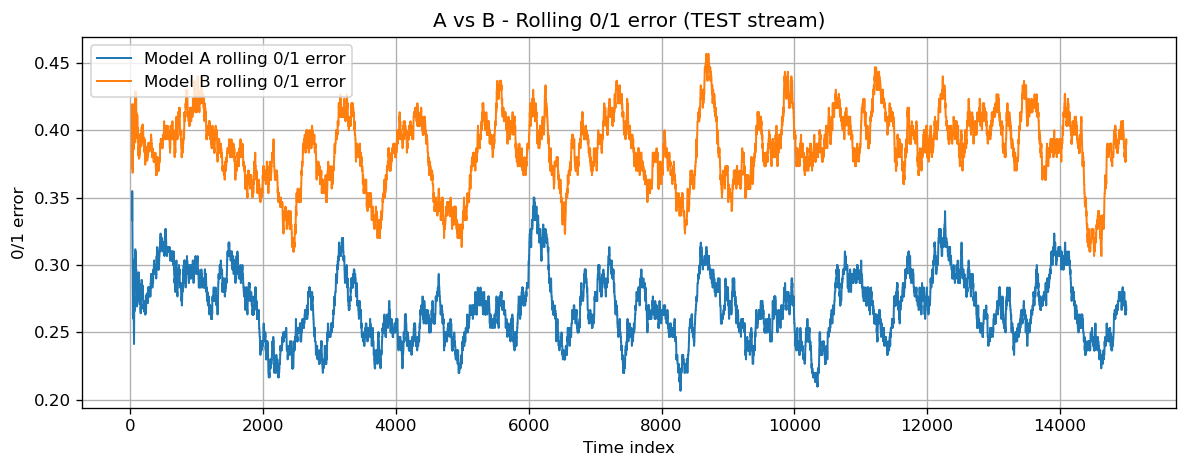

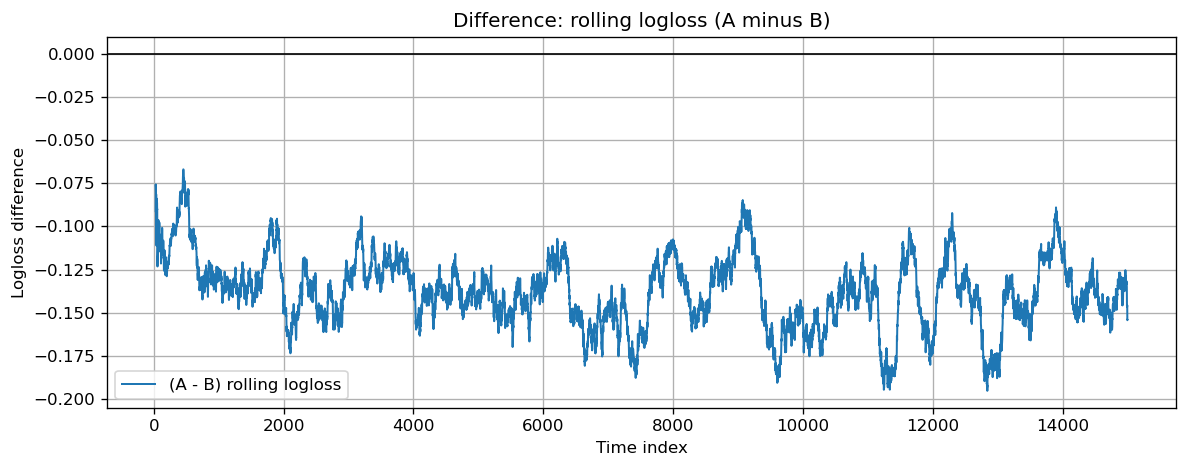

In [27]:
t = resA["t"]

llA = rolling_mean(resA["test_ll"], ROLLING_WINDOW)
llB = rolling_mean(resB["test_ll"], ROLLING_WINDOW)

erA = rolling_mean(resA["test_err01"], ROLLING_WINDOW)
erB = rolling_mean(resB["test_err01"], ROLLING_WINDOW)

# 1) Rolling logloss overlay
plt.figure(figsize=(10, 4))
plt.plot(t, llA, label="Model A rolling logloss", linewidth=1.2)
plt.plot(t, llB, label="Model B rolling logloss", linewidth=1.2)
plt.title("A vs B - Rolling logloss (TEST stream)")
plt.xlabel("Time index")
plt.ylabel("Logloss")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Rolling 0/1 error overlay
plt.figure(figsize=(10, 4))
plt.plot(t, erA, label="Model A rolling 0/1 error", linewidth=1.2)
plt.plot(t, erB, label="Model B rolling 0/1 error", linewidth=1.2)
plt.title("A vs B - Rolling 0/1 error (TEST stream)")
plt.xlabel("Time index")
plt.ylabel("0/1 error")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Difference plot (A - B) on rolling logloss
plt.figure(figsize=(10, 4))
plt.plot(t, llA - llB, label="(A - B) rolling logloss", linewidth=1.2)
plt.axhline(0.0, color="black", linewidth=1.0)
plt.title("Difference: rolling logloss (A minus B)")
plt.xlabel("Time index")
plt.ylabel("Logloss difference")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
import numpy as np
import pandas as pd

def _first_time_or_inf(x):
    return float("inf") if x is None else float(x)

def compare_models_drift(resA, resB):
    """
    Expects resA/resB dicts produced by your run_stream_drift().

    Required keys (most drift pipelines already store these):
      - name
      - metrics_test : dict with keys like 'logloss', 'roc_auc', 'accuracy@0.5'
      - cusum_ll_first, ph_ll_first, cusum_er_first, ph_er_first
      - test_ll, test_err01  (arrays over the TEST stream)
    """

    # ---------- 1) Performance on newest data ----------
    A_ll = resA["metrics_test"]["logloss"]
    B_ll = resB["metrics_test"]["logloss"]

    A_auc = resA["metrics_test"]["roc_auc"]
    B_auc = resB["metrics_test"]["roc_auc"]

    A_acc = resA["metrics_test"]["accuracy@0.5"]
    B_acc = resB["metrics_test"]["accuracy@0.5"]

    # lower is better
    win_ll = "A" if A_ll < B_ll else ("B" if B_ll < A_ll else "tie")
    # higher is better
    win_auc = "A" if A_auc > B_auc else ("B" if B_auc > A_auc else "tie")
    win_acc = "A" if A_acc > B_acc else ("B" if B_acc > A_acc else "tie")

    # ---------- 2) Drift stability ----------
    # Later drift = more stable; None means "no drift detected" => treat as +infinity (best)
    A_first = min(
        _first_time_or_inf(resA.get("cusum_ll_first")),
        _first_time_or_inf(resA.get("ph_ll_first")),
        _first_time_or_inf(resA.get("cusum_er_first")),
        _first_time_or_inf(resA.get("ph_er_first")),
    )
    B_first = min(
        _first_time_or_inf(resB.get("cusum_ll_first")),
        _first_time_or_inf(resB.get("ph_ll_first")),
        _first_time_or_inf(resB.get("cusum_er_first")),
        _first_time_or_inf(resB.get("ph_er_first")),
    )

    # Average error in the TEST stream (smaller is better)
    A_ll_mean = float(np.mean(resA["test_ll"]))
    B_ll_mean = float(np.mean(resB["test_ll"]))
    A_er_mean = float(np.mean(resA["test_err01"]))
    B_er_mean = float(np.mean(resB["test_err01"]))

    # Drift winner: later first drift AND lower mean error (simple combined logic)
    drift_score_A = 0
    drift_score_B = 0

    # Later drift time is better
    if A_first > B_first:
        drift_score_A += 1
    elif B_first > A_first:
        drift_score_B += 1

    # Lower mean test logloss is better
    if A_ll_mean < B_ll_mean:
        drift_score_A += 1
    elif B_ll_mean < A_ll_mean:
        drift_score_B += 1

    # Lower mean test 0/1 error is better
    if A_er_mean < B_er_mean:
        drift_score_A += 1
    elif B_er_mean < A_er_mean:
        drift_score_B += 1

    # ---------- 3) Final decision ----------
    # Performance score from (logloss, AUC, accuracy)
    perf_score_A = sum([win_ll == "A", win_auc == "A", win_acc == "A"])
    perf_score_B = sum([win_ll == "B", win_auc == "B", win_acc == "B"])

    total_A = perf_score_A + drift_score_A
    total_B = perf_score_B + drift_score_B

    if total_A > total_B:
        winner = "Model A"
    elif total_B > total_A:
        winner = "Model B"
    else:
        winner = "Tie (depends on your priority)"

    # ---------- 4) Print explanation ----------
    def fmt_time(x):
        return "No drift detected" if x is None else str(x)

    summary = pd.DataFrame([
        {
            "Model": "A",
            "Test logloss (global)": A_ll,
            "Test ROC-AUC (global)": A_auc,
            "Test accuracy@0.5 (global)": A_acc,
            "First drift (any detector)": "No drift detected" if np.isinf(A_first) else int(A_first),
            "Mean TEST logloss (stream)": A_ll_mean,
            "Mean TEST 0/1 error (stream)": A_er_mean,
        },
        {
            "Model": "B",
            "Test logloss (global)": B_ll,
            "Test ROC-AUC (global)": B_auc,
            "Test accuracy@0.5 (global)": B_acc,
            "First drift (any detector)": "No drift detected" if np.isinf(B_first) else int(B_first),
            "Mean TEST logloss (stream)": B_ll_mean,
            "Mean TEST 0/1 error (stream)": B_er_mean,
        }
    ])

    print("=== Metrics + Drift Summary ===")
    display(summary.style.format(precision=4))

    print("\n=== Decision ===")
    print("Winner:", winner)

    print("\n=== Why (simple explanation) ===")
    print("- Performance on newest data (TEST):")
    print(f"  - Lower logloss is better -> winner: {win_ll}")
    print(f"  - Higher ROC-AUC is better -> winner: {win_auc}")
    print(f"  - Higher accuracy is better -> winner: {win_acc}")

    print("- Drift stability (TEST stream):")
    print(f"  - Earlier drift detection means the model became unreliable sooner (worse). [file:4]")
    print(f"  - Model A first drift: {('No drift detected' if np.isinf(A_first) else int(A_first))}")
    print(f"  - Model B first drift: {('No drift detected' if np.isinf(B_first) else int(B_first))}")
    print(f"  - Mean stream logloss (lower better): A={A_ll_mean:.4f}, B={B_ll_mean:.4f}")
    print(f"  - Mean stream 0/1 error (lower better): A={A_er_mean:.4f}, B={B_er_mean:.4f}")

    return {"winner": winner, "summary": summary}

# Run it:
decision = compare_models_drift(resA, resB)

=== Metrics + Drift Summary ===


,Model,Test logloss (global),Test ROC-AUC (global),Test accuracy@0.5 (global),First drift (any detector),Mean TEST logloss (stream),Mean TEST 0/1 error (stream)
0,A,0.5030,0.7902,0.7318,1975,0.5030,0.2682
1,B,0.6415,0.6525,0.6139,2212,0.6415,0.3861



=== Decision ===
Winner: Model A

=== Why (simple explanation) ===
- Performance on newest data (TEST):
  - Lower logloss is better -> winner: A
  - Higher ROC-AUC is better -> winner: A
  - Higher accuracy is better -> winner: A
- Drift stability (TEST stream):
  - Earlier drift detection means the model became unreliable sooner (worse). [file:4]
  - Model A first drift: 1975
  - Model B first drift: 2212
  - Mean stream logloss (lower better): A=0.5030, B=0.6415
  - Mean stream 0/1 error (lower better): A=0.2682, B=0.3861
